In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import random
import shutil
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import callbacks
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10

In [ ]:
dataset_path = "/content/drive/MyDrive/Kidney_Data/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"
output_dir = "/content/drive/MyDrive/Kidney_Data/Models"
os.makedirs(output_dir, exist_ok=True)

In [ ]:
all_images = []
all_labels = []

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            all_images.append(img_path)
            all_labels.append(class_name)

df = pd.DataFrame({"image": all_images, "label": all_labels})

train_df, temp_df = train_test_split(df, test_size=0.4, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [ ]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="image",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

Found 7467 validated image filenames belonging to 4 classes.


In [ ]:
val_generator = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col="image",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

Found 2489 validated image filenames belonging to 4 classes.


In [ ]:
test_generator = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col="image",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 2490 validated image filenames belonging to 4 classes.


In [ ]:
def show_images(path,title,cmap=None):
    labels = list(os.listdir(path))
    fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))
    random_indices = random.sample(range(1, 101), 10)

    for i, idx in enumerate(random_indices, 1):
        file_path = os.path.join(path, labels[idx])
        image = Image.open(file_path)
        subplot_row = (i - 1) // 5
        subplot_col = (i - 1) % 5
        axes[subplot_row, subplot_col].imshow(image, cmap=cmap)
        axes[subplot_row, subplot_col].axis('off')
    plt.suptitle(title, fontsize=20)
    plt.tight_layout()
    plt.show()

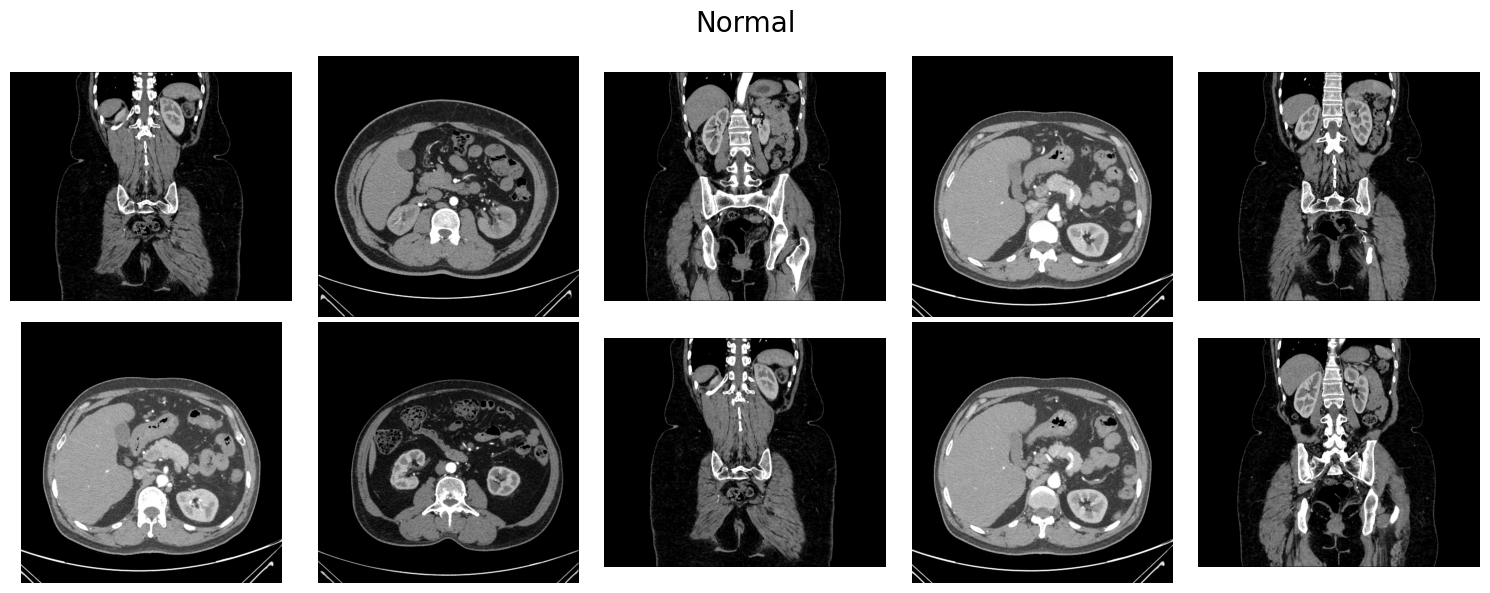

In [ ]:
show_images(os.path.join(dataset_path+"/Normal"),"Normal")

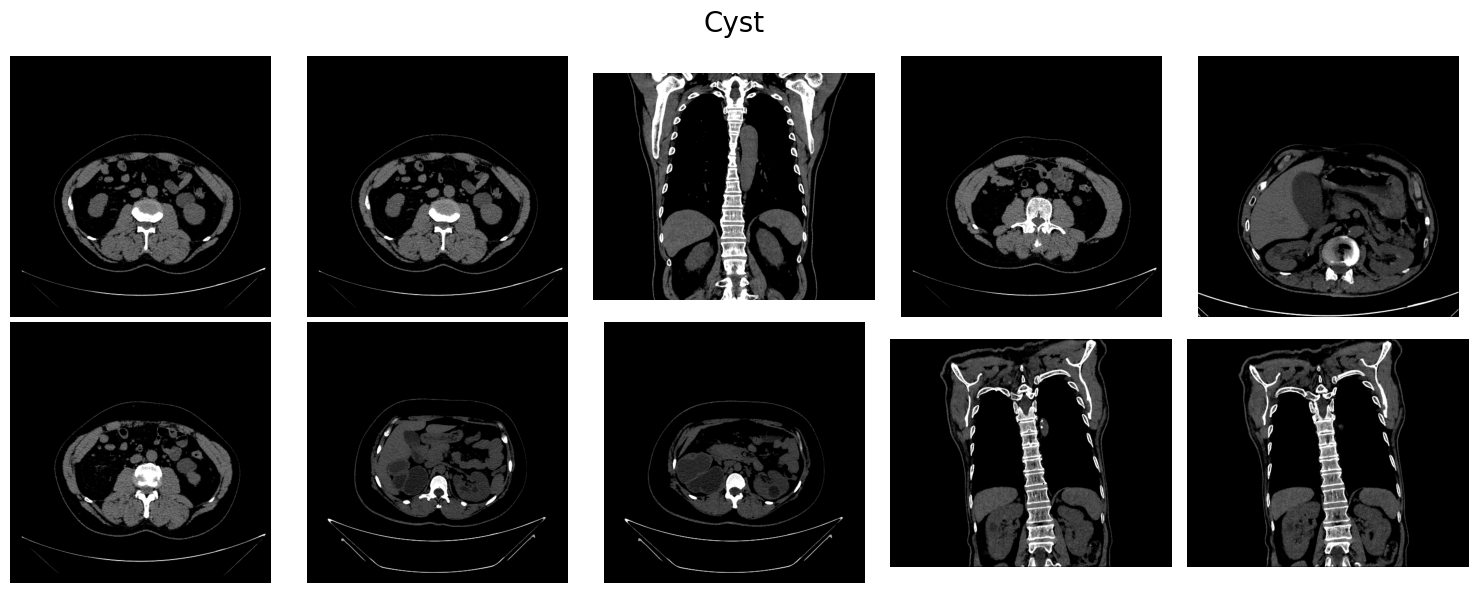

In [ ]:
show_images(os.path.join(dataset_path+"/Cyst"),"Cyst")

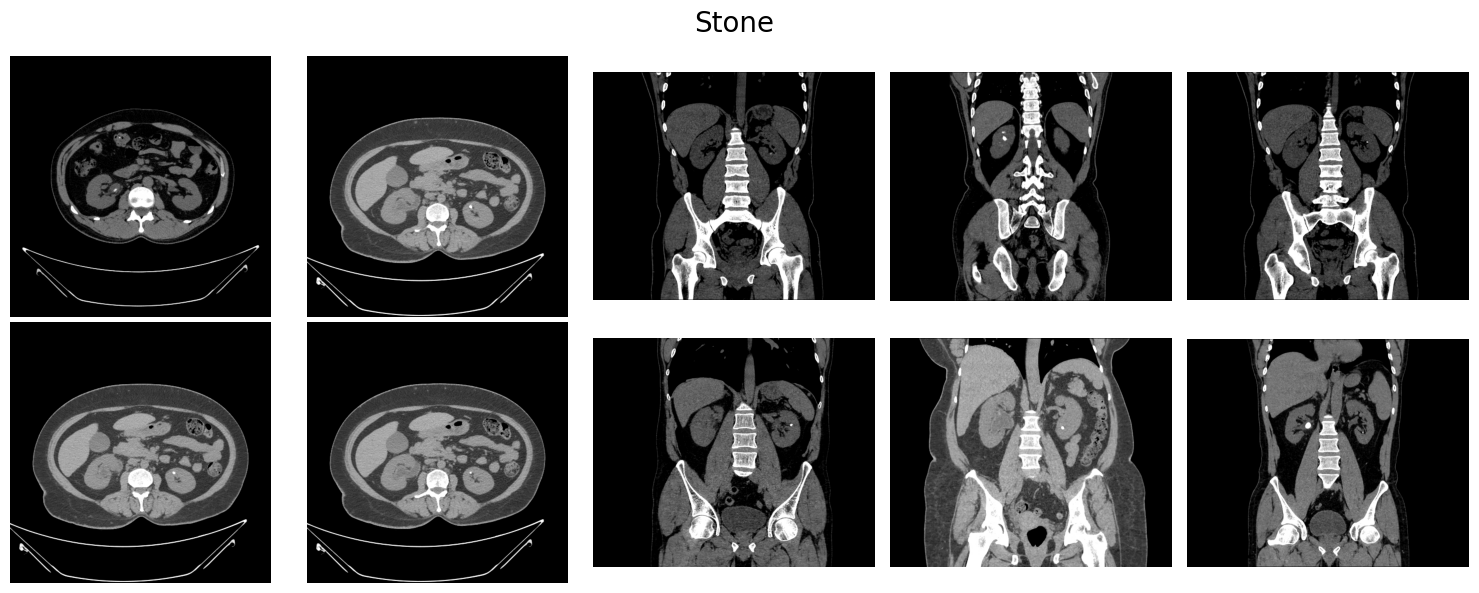

In [ ]:
show_images(os.path.join(dataset_path+"/Stone"),"Stone")

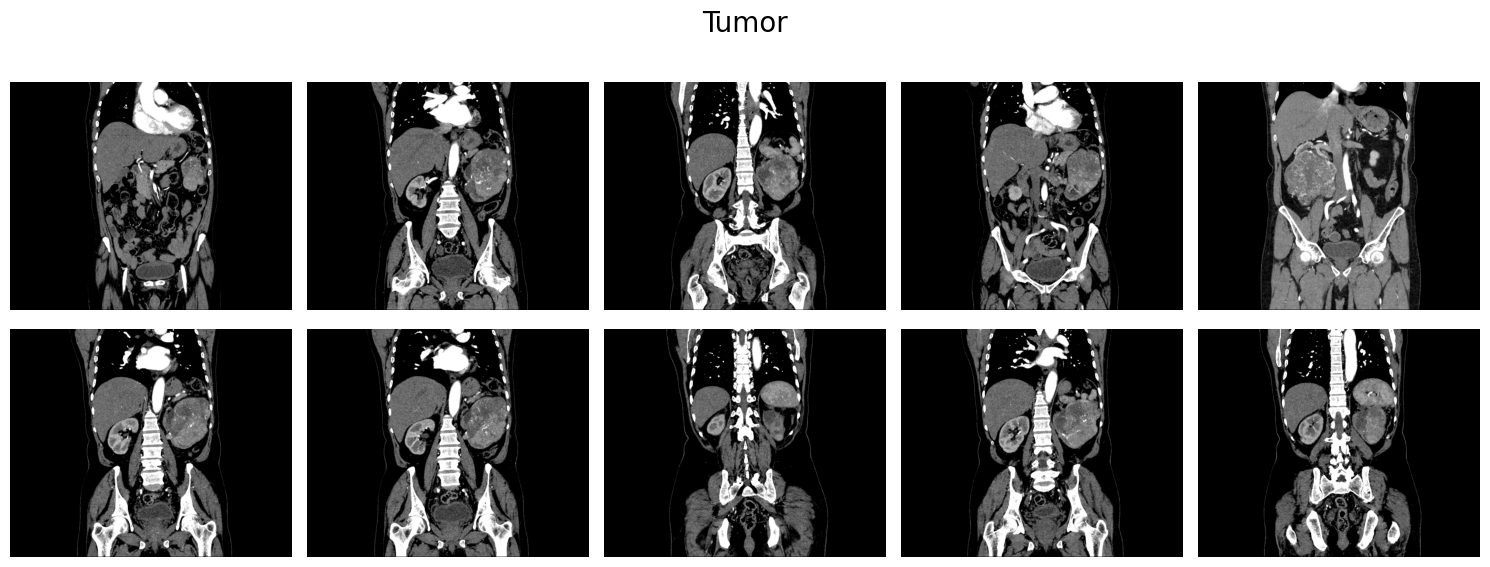

In [ ]:
show_images(os.path.join(dataset_path+"/Tumor"),"Tumor")

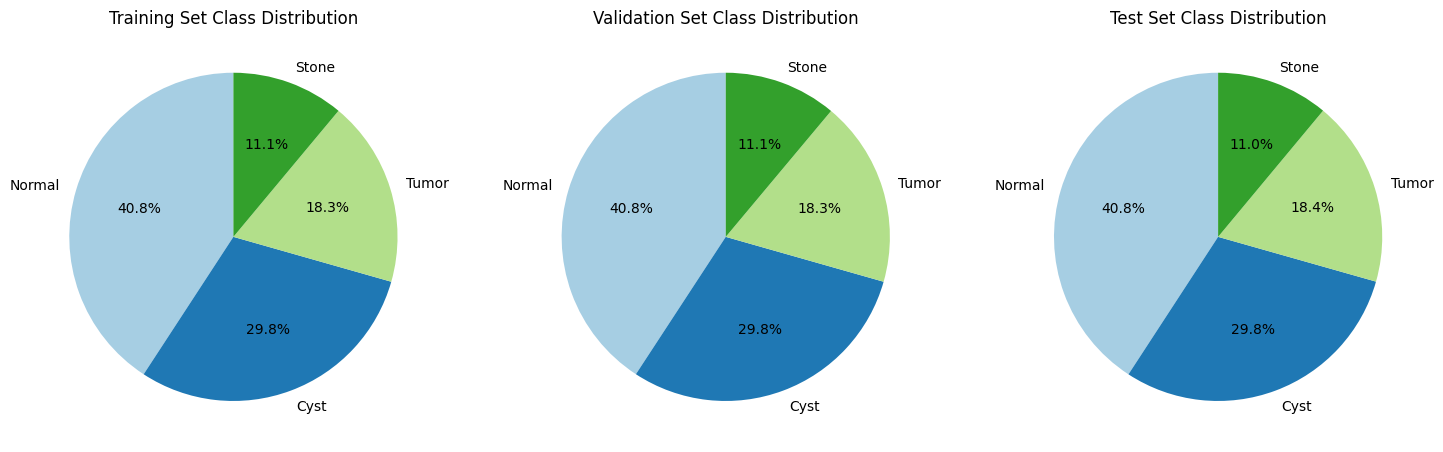

In [ ]:
def plot_class_distribution(df, title, subplot_idx):
    class_counts = df["label"].value_counts()
    plt.subplot(1, 3, subplot_idx)
    plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
    plt.title(title)

plt.figure(figsize=(18, 6))
plot_class_distribution(train_df, "Training Set Class Distribution", 1)
plot_class_distribution(val_df, "Validation Set Class Distribution", 2)
plot_class_distribution(test_df, "Test Set Class Distribution", 3)
plt.show()

In [ ]:
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dense(128, activation="relu")(x)
x = Dense(64, activation="relu")(x)
x = Dense(len(df["label"].unique()), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=x)

In [ ]:
lr_callback = callbacks.ReduceLROnPlateau(monitor = 'val_recall', factor = 0.1, patience = 5)
stop_callback = callbacks.EarlyStopping(monitor = 'val_recall', patience = 5)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks = [lr_callback, stop_callback]
)

Epoch 1/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 3737s 16s/step - accuracy: 0.7176 - loss: 0.7575 - precision: 0.8376 - recall: 0.5669 - val_accuracy: 0.8301 - val_loss: 0.4863 - val_precision: 0.8586 - val_recall: 0.7879 - learning_rate: 1.0000e-04
Epoch 2/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 163s 696ms/step - accuracy: 0.8512 - loss: 0.4112 - precision: 0.8802 - recall: 0.8130 - val_accuracy: 0.8582 - val_loss: 0.3754 - val_precision: 0.8774 - val_recall: 0.8365 - learning_rate: 1.0000e-04
Epoch 3/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 159s 678ms/step - accuracy: 0.8907 - loss: 0.3092 - precision: 0.9121 - recall: 0.8716 - val_accuracy: 0.8863 - val_loss: 0.3096 - val_precision: 0.9014 - val_recall: 0.8702 - learning_rate: 1.0000e-04
Epoch 4/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 156s 668ms/step - accuracy: 0.9061 - loss: 0.2586 - precision: 0.9205 - recall: 0.8919 - val_accuracy: 0.8767 - val_loss: 0.3202 - val_precision: 0.8886 - val_recall: 0.8622 - learning_rate: 1.0000e-04
Epoch 5/10
234/234 ━━━━━━━━━━━━━━

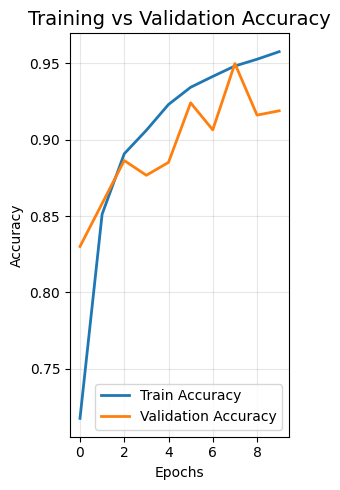

In [ ]:
plt.figure(figsize=(8, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy", linewidth=2)
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy", fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

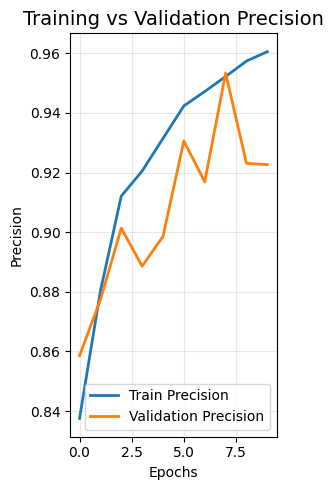

In [ ]:
plt.figure(figsize=(8, 5))

plt.subplot(1, 3, 2)
plt.plot(history.history["precision"], label="Train Precision", linewidth=2)
plt.plot(history.history["val_precision"], label="Validation Precision", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Precision")
plt.legend()
plt.title("Training vs Validation Precision", fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

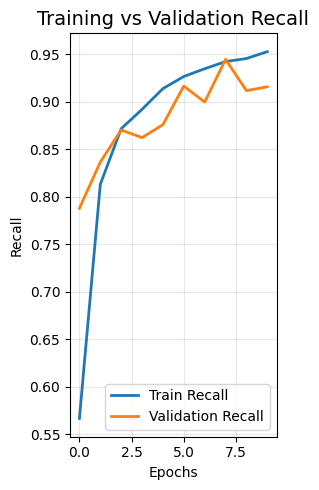

In [ ]:
plt.figure(figsize=(8, 5))

plt.subplot(1, 3, 3)
plt.plot(history.history["recall"], label="Train Recall", linewidth=2)
plt.plot(history.history["val_recall"], label="Validation Recall", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Recall")
plt.legend()
plt.title("Training vs Validation Recall", fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc, test_precision, test_recall = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

78/78 ━━━━━━━━━━━━━━━━━━━━ 907s 12s/step - accuracy: 0.9249 - loss: 0.2175 - precision: 0.9320 - recall: 0.9197
Test Accuracy: 0.9249
Test Precision: 0.9320
Test Recall: 0.9197


In [ ]:
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices.keys()))

78/78 ━━━━━━━━━━━━━━━━━━━━ 27s 297ms/step
Classification Report:
              precision    recall  f1-score   support

        Cyst       0.90      0.99      0.94       742
      Normal       0.98      0.91      0.95      1016
       Stone       0.76      0.89      0.82       275
       Tumor       0.97      0.86      0.91       457

    accuracy                           0.92      2490
   macro avg       0.90      0.91      0.91      2490
weighted avg       0.93      0.92      0.93      2490



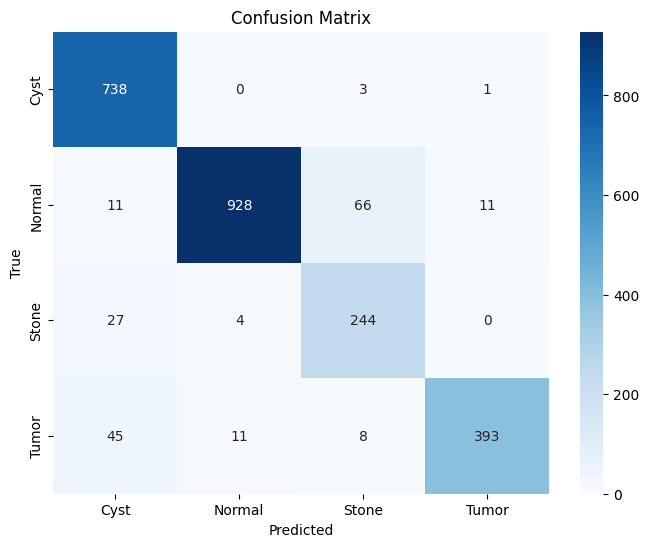

In [ ]:
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
drive.mount('/content/drive')

drive_dir = "/content/drive/MyDrive/Kidney_Data/Model"

resnet_path = f"{drive_dir}/resnet50_kidney_ct.h5"
model.save(resnet_path)
print("✅ Saved ResNet model to:", resnet_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Saved ResNet model to: /content/drive/MyDrive/Kidney_Data/Model/resnet50_kidney_ct.h5


In [ ]:
from google.colab import files

files.download("/content/drive/MyDrive/Kidney_Data/Model/resnet50_kidney_ct.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

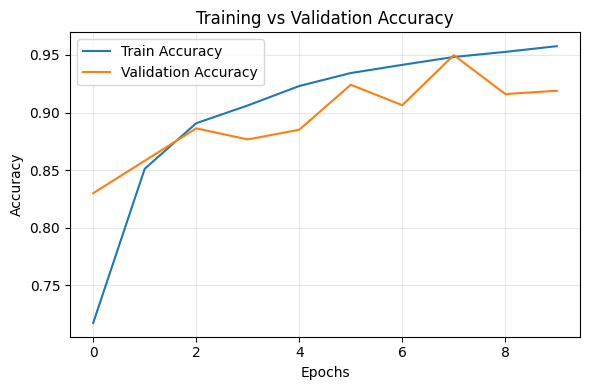

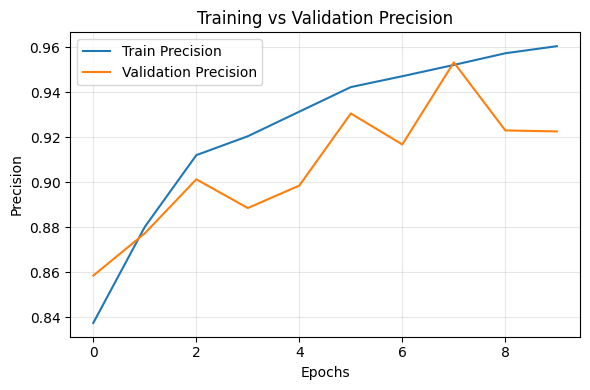

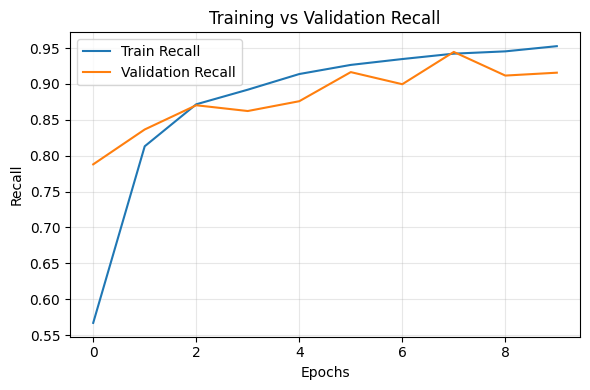

In [ ]:
save_dir = "/content/drive/MyDrive/Kidney_Data/Model"  # same place as models
os.makedirs(save_dir, exist_ok=True)

# Accuracy
plt.figure(figsize=(6, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "resnet_accuracy.png"), dpi=300)
plt.show()

# Precision
plt.figure(figsize=(6, 4))
plt.plot(history.history["precision"], label="Train Precision")
plt.plot(history.history["val_precision"], label="Validation Precision")
plt.xlabel("Epochs")
plt.ylabel("Precision")
plt.legend()
plt.title("Training vs Validation Precision")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "resnet_precision.png"), dpi=300)
plt.show()

# Recall
plt.figure(figsize=(6, 4))
plt.plot(history.history["recall"], label="Train Recall")
plt.plot(history.history["val_recall"], label="Validation Recall")
plt.xlabel("Epochs")
plt.ylabel("Recall")
plt.legend()
plt.title("Training vs Validation Recall")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "resnet_recall.png"), dpi=300)
plt.show()

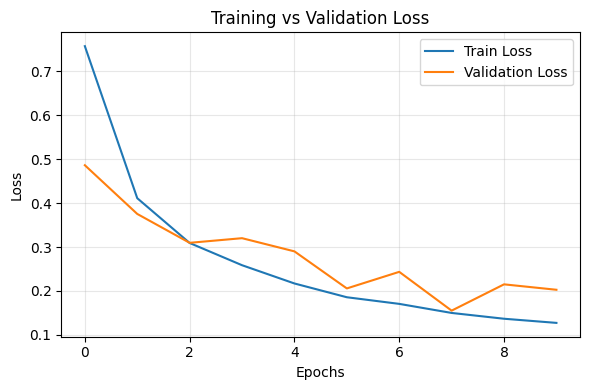

In [ ]:
# Loss
plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "resnet_loss.png"), dpi=300)
plt.show()

78/78 ━━━━━━━━━━━━━━━━━━━━ 19s 240ms/step


<Figure size 600x600 with 0 Axes>

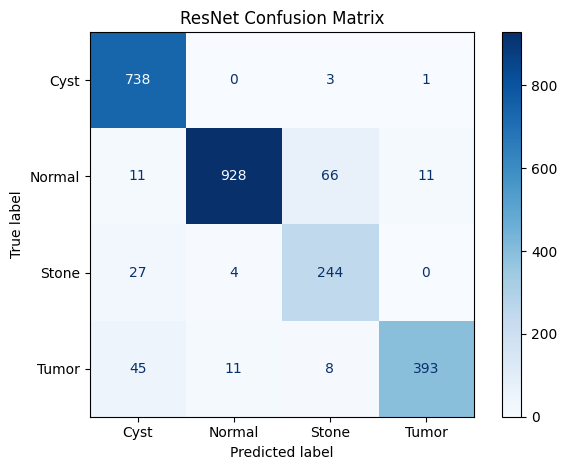

              precision    recall  f1-score   support

        Cyst       0.90      0.99      0.94       742
      Normal       0.98      0.91      0.95      1016
       Stone       0.76      0.89      0.82       275
       Tumor       0.97      0.86      0.91       457

    accuracy                           0.92      2490
   macro avg       0.90      0.91      0.91      2490
weighted avg       0.93      0.92      0.93      2490



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Get true labels & predictions from test generator
test_steps = len(test_generator)
y_true = test_generator.classes                      # true labels
class_names = list(test_generator.class_indices.keys())

y_pred_probs = model.predict(test_generator, steps=test_steps, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("ResNet Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "resnet_confusion_matrix.png"), dpi=300)
plt.show()

# 3. Classification report → text file
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

with open(os.path.join(save_dir, "resnet_classification_report.txt"), "w") as f:
    f.write(report)

In [ ]:
import shutil
from google.colab import drive, files
import os

# Make sure Drive is mounted
drive.mount('/content/drive', force_remount=False)

model_dir = "/content/drive/MyDrive/Kidney_Data/Model"
zip_path = "/content/kidney_resnet_model.zip"

# Create ZIP of the whole folder
shutil.make_archive(zip_path.replace(".zip", ""), 'zip', model_dir)
print("✅ ZIP created at:", zip_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ ZIP created at: /content/kidney_resnet_model.zip


In [ ]:
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>